In [3]:
import math
import torch
import matplotlib.pyplot as plt

In [4]:
results = torch.load('RLM_results/rlm64L1_b2_6.pt', weights_only=False)
dynamics = results['output']['dynamics']
config = results['config']

In [5]:
results = {}
dynamics = {}
configs = {}

for i in range(7):
    i +=1
    path = f'RLM_results/rlm64L1_b2_ts32768_{i}.pt'
    results[i] = torch.load(path, weights_only=False)
    dynamics[i] = results[i]['output']['dynamics']
    configs[i] = results[i]['config']


TypeError: 'int' object is not subscriptable

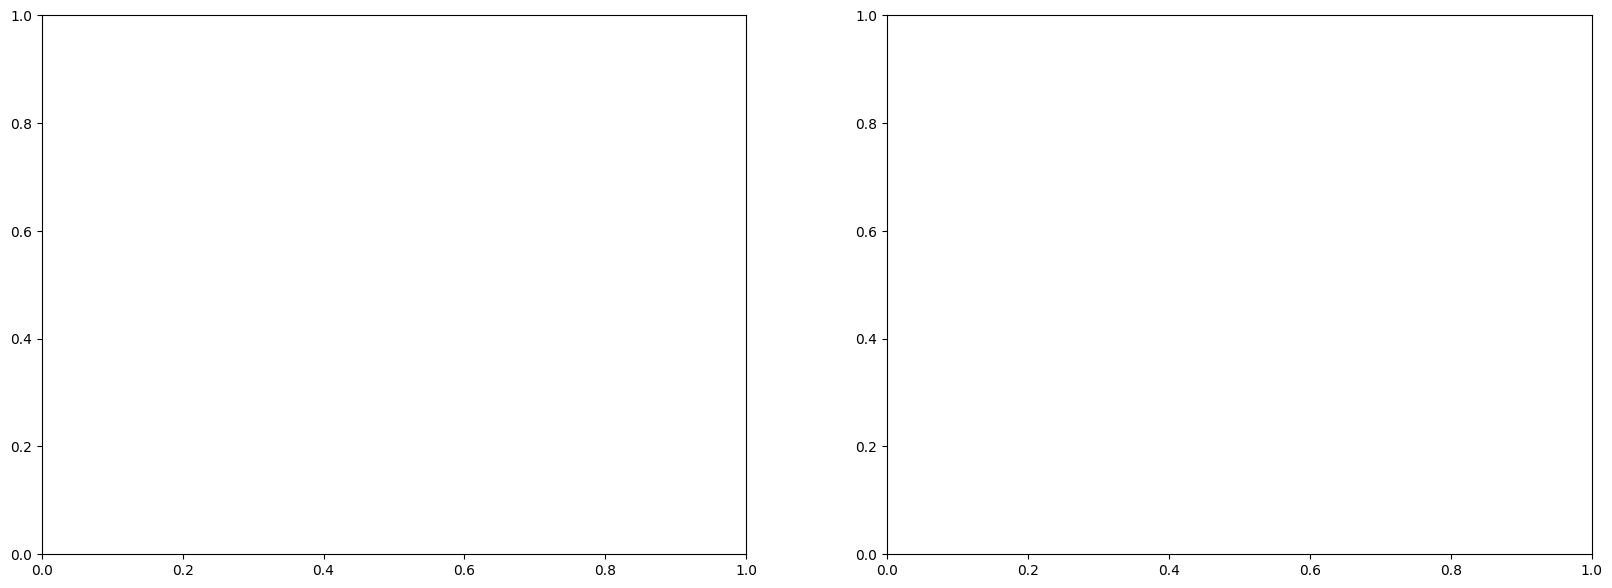

In [6]:


fig, ax = plt.subplots(1, 2, figsize=(20,7))

ax[0].plot([d['t'] for d in dynamics], [d['testloss'] for d in dynamics], f'C1', label='test loss B' + str(config.beta))
ax[1].plot([d['t'] for d in dynamics], [d['testacc'] for d in dynamics], f'C1', label='test accuracy B' + str(config.beta))

if config.measure_train:
    ax[0].plot([d['t'] for d in dynamics], [d['trainloss'] for d in dynamics], f'C0', label='training loss')
    ax[1].plot([d['t'] for d in dynamics], [d['trainacc'] for d in dynamics], f'C0', label='training accuracy')

ax[0].plot([d['t'] for d in dynamics], [results['output']['entropy'] for d in dynamics], 'k--')

ax[0].legend()
ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].legend()
ax[1].set_xscale('log')

In [7]:
results = {}
dynamics = {}
configs = {}

train_size = 2**18

for i in range(7):
    i +=1
    path = f'RLM_results/rlm64L1_b2_ts{train_size}_{i}.pt'
    results[i] = torch.load(path, weights_only=False)
    dynamics[i] = results[i]['output']['dynamics']
    configs[i] = results[i]['config']


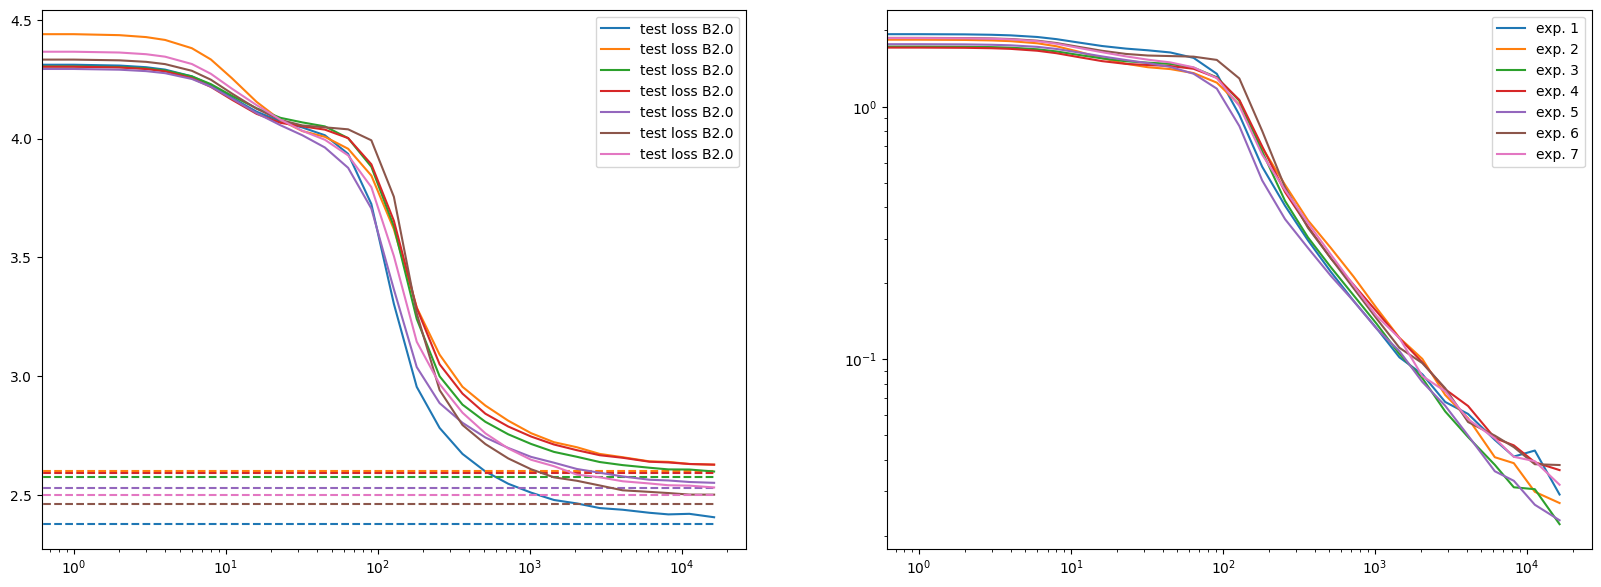

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(20,7))
test_loss_mean = []

for i in range(1, 8):
    dyn = dynamics[i]
    conf = configs[i]
    t = [d['t'] for d in dyn]
    test_loss = [d['testloss'] for d in dyn]
    ax[0].plot(t, test_loss, f'C{i-1}', label=f'test loss B{conf.beta}')
    test_loss_mean += test_loss
    ax[0].plot([d['t'] for d in dynamics[i]], [results[i]['output']['entropy'] for d in dynamics[i]], f'C{i-1}', linestyle='dashed')
    ax[1].plot(t,[d['testloss']-results[i]['output']['entropy'] for d in dyn], f'C{i-1}', label=f'exp. {i}')

ax[0].set_xscale('log')
ax[0].legend()

ax[1].set_yscale('log')
ax[1].set_xscale('log')

ax[1].legend()

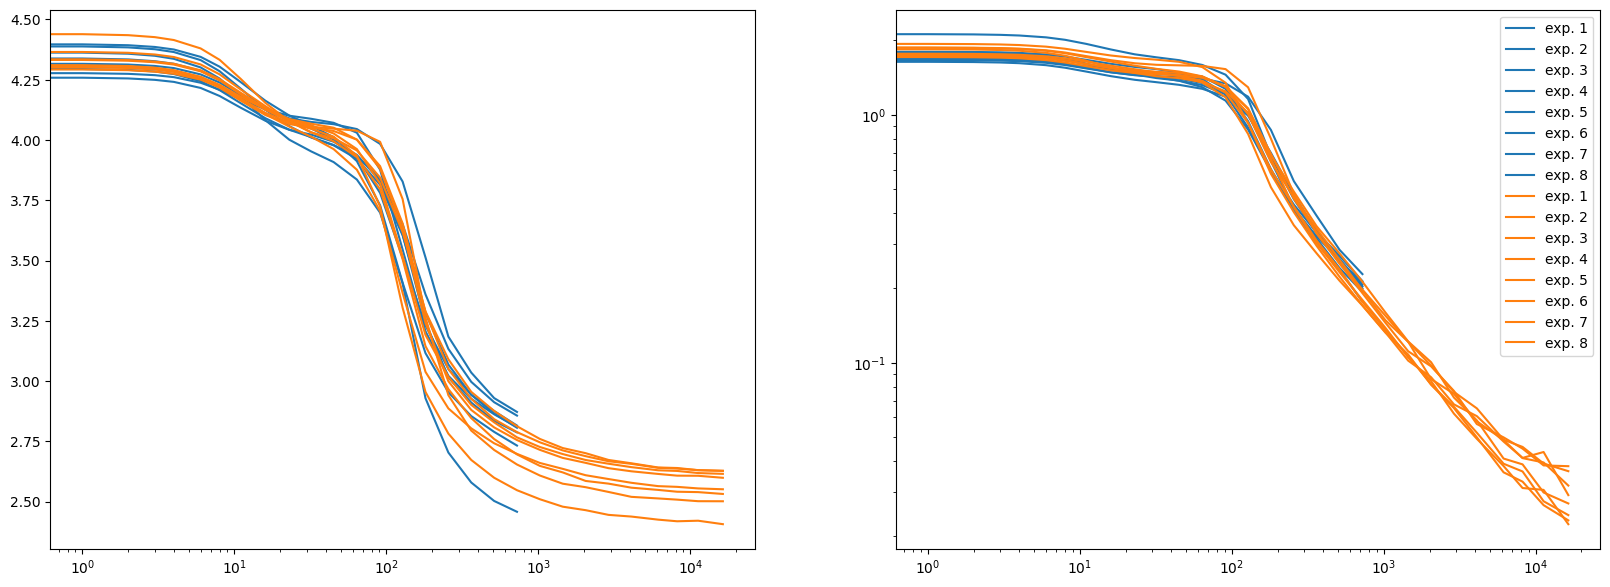

In [77]:
fig, ax = plt.subplots(1, 2, figsize=(20,7))
test_loss_mean = []

nexp = 8
path = f'RLM_results/'


for i_ts, train_size in enumerate([2**15, 2**18]):

    prefix = f'rlm64L1_b2_ts{train_size}'

    for i in range(1,nexp+1):

        results = torch.load(path+prefix+f'_{i}.pt', weights_only=False)
        dyn = results['output']['dynamics']
        entropy = results['output']['entropy']
        conf = results['config']
        t = [d['t'] for d in dyn]
        test_loss = [d['testloss'] for d in dyn]
        ax[0].plot(t, test_loss, f'C{i_ts}', label=f'ts = {train_size}')
        # ax[0].plot(t, [entropy for d in dyn], f'C{i_ts}', linestyle='dashed')
        ax[1].plot(t,[d['testloss']-entropy for d in dyn], f'C{i_ts}', label=f'exp. {i}')

ax[0].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].legend()